# Zomato Data Analysis Using Python

Understanding customer preferences and restaurant trends is important for making informed business decisions in food industry. In this article, we will analyze Zomato’s restaurant dataset using Python to find meaningful insights. We aim to answer questions such as:

Do more restaurants provide online delivery compared to offline services?
Which types of restaurants are most favored by the general public?
What price range do couples prefer for dining out?

## Implementation for Zomato Data Analysis using Python.
Below steps are followed for its implementation.

### Step 1: Importing necessary Python libraries.

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2 Creating the data frame.  

In [3]:
# importing data 
df = pd.read_csv(r"C:\Users\ADMIN\Downloads\Zomato-data-.csv")
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1/5,775,800,Buffet
1,Spice Elephant,Yes,No,4.1/5,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8/5,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7/5,88,300,Buffet
4,Grand Village,No,No,3.8/5,166,600,Buffet


## Step 3: Data Cleaning and Preparation

In [10]:
df.shape

(148, 7)

### Observations
This data set has 148 row and 7 columns

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148 entries, 0 to 147
Data columns (total 7 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   name                         148 non-null    object
 1   online_order                 148 non-null    object
 2   book_table                   148 non-null    object
 3   rate                         148 non-null    object
 4   votes                        148 non-null    int64 
 5   approx_cost(for two people)  148 non-null    int64 
 6   listed_in(type)              148 non-null    object
dtypes: int64(2), object(5)
memory usage: 8.2+ KB


### Observation
This Dataset has 148 rows, 7 columns, no missing values, with categorical and numeric fields suitable for cleaning and analysis.

In [16]:
df.describe()

,votes,approx_cost(for two people)
count,148.000000,148.000000
mean,264.810811,418.243243
std,653.676951,223.085098
min,0.000000,100.000000
25%,6.750000,200.000000
50%,43.500000,400.000000
75%,221.750000,600.000000
max,4884.000000,950.000000


## Type of resturant

In [52]:
df.head()

,name,online_order,book_table,rate,votes,approx_cost(for two people),listed_in(type)
0,Jalsa,Yes,Yes,4.1,775,800,Buffet
1,Spice Elephant,Yes,No,4.1,787,800,Buffet
2,San Churro Cafe,Yes,No,3.8,918,800,Buffet
3,Addhuri Udupi Bhojana,No,No,3.7,88,300,Buffet
4,Grand Village,No,No,3.8,166,600,Buffet


 ## Step 4 Exploring Restaurant Types

Text(0.5, 0, 'type of resturant')

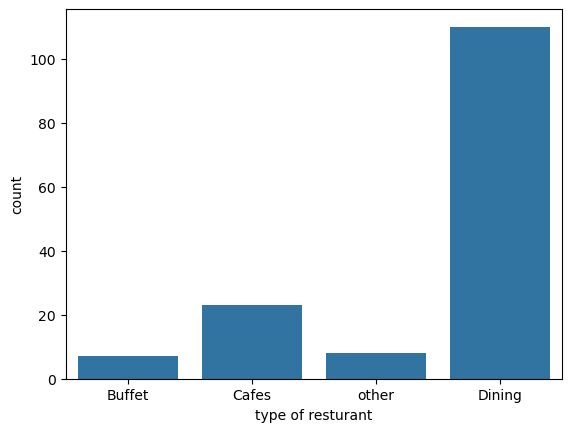

In [53]:
sns.countplot(x=df['listed_in(type)'])
plt.xlabel("type of resturant")

### Observation
majority of the resturant falls in dinning caregory

Text(0, 0.5, 'Votes')

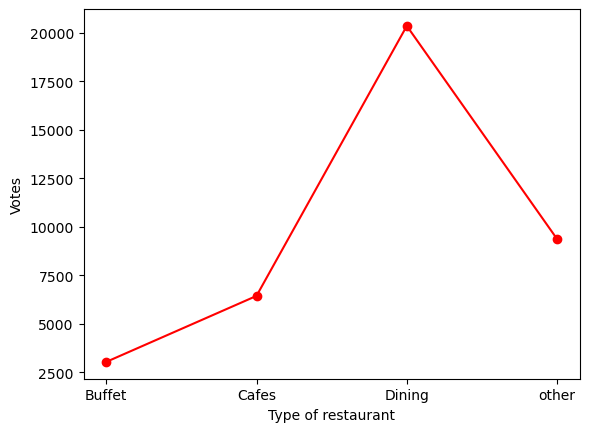

In [56]:
grouped_data = df.groupby('listed_in(type)')['votes'].sum()
result = pd.DataFrame({'votes': grouped_data})
plt.plot(result, c='red', marker='o')
plt.xlabel('Type of restaurant')
plt.ylabel('Votes')

### Observation
Dining restaurants are preferred by a larger number of individuals.


## Step 5 Analyze Ratings

Text(0.5, 1.0, 'Rating distribution')

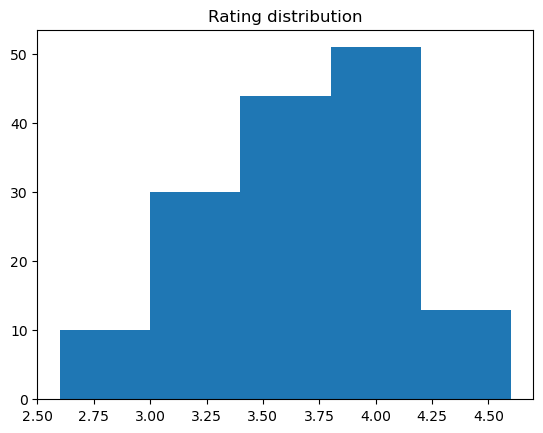

In [58]:
plt.hist(df['rate'],bins = 5)
plt.title("Rating distribution")

### Observation
The majority of restaurants received ratings ranging from 3.5 to 4.

## Step 6: Online Order Availability

<Axes: xlabel='online_order', ylabel='count'>

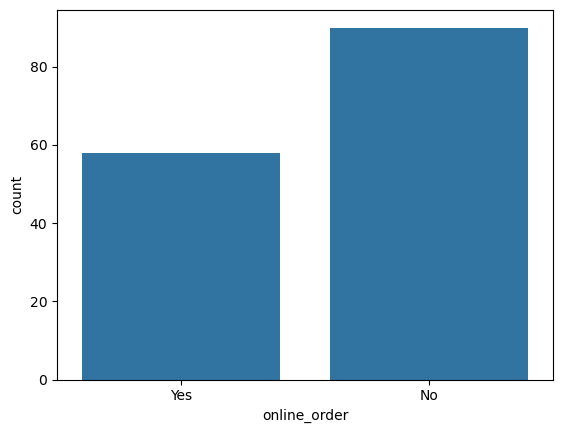

In [60]:
sns.countplot(x=df['online_order'])

## Observation
 This suggests that a majority of the restaurants do not accept online orders.

## Step 7: Ratings Comparison - Online vs Offline Orders

<Axes: xlabel='approx_cost(for two people)', ylabel='count'>

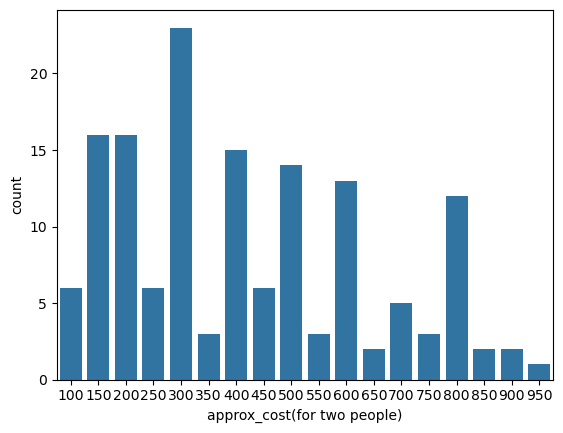

In [67]:
couple_data=df['approx_cost(for two people)']
sns.countplot(x=couple_data)

### Observation
The majority of couples prefer restaurants with an approximate cost of 300 rupees.

## Step 8 Which mode receives maximum rating

<Axes: xlabel='online_order', ylabel='rate'>

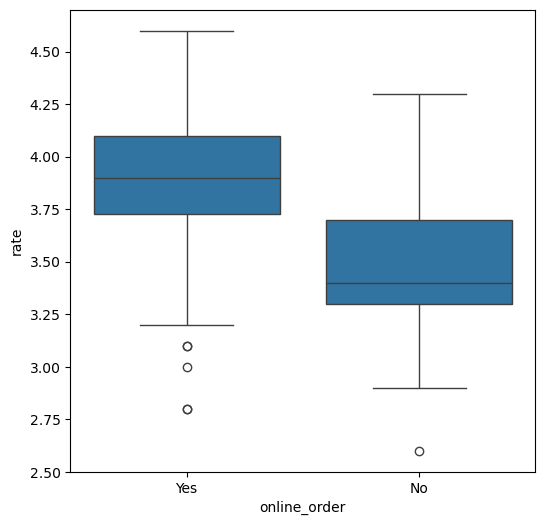

In [68]:
plt.figure(figsize = (6,6))
sns.boxplot(x = 'online_order', y = 'rate', data = df)

### Observation
offline order received lower rating in comparison to online order

## Step 9 Order Mode Preferences by Restaurant Type

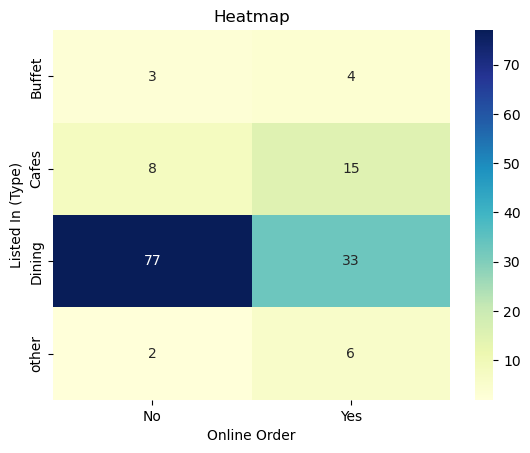

In [69]:
pivot_table = df.pivot_table(index='listed_in(type)', columns='online_order', aggfunc='size', fill_value=0)
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Heatmap')
plt.xlabel('Online Order')
plt.ylabel('Listed In (Type)')
plt.show()

### Observation
With this we can say that dining restaurants primarily accept offline orders whereas cafes primarily receive online orders. This suggests that clients prefer to place orders in person at restaurants but prefer online ordering at cafes.